In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import trimesh

In [2]:
df = pd.read_pickle('./data.pkl')

In [3]:
# TPC boundaries (cm)
tpcMinX = -200
tpcMaxX = 200
tpcMinY = -200
tpcMaxY = 200
tpcMinZ = 0
tpcMaxZ = 500
tpcProjZFront = tpcMinZ

'''
# Fiducial volume boundaries (cm)
tpcMinX = -183.5
tpcMaxX = 183.5
tpcMinY = -185
tpcMaxY = 185
tpcMinZ = 40 # start of the fiducial volume, where 0 is the front face of the tpc
tpcMaxZ = 460
tpcProjZFront = 0
'''

# Beam center (cm)
beamCenterX = -74
beamCenterY = 0
beamCenterZ = 11000 # front face of the tpc, where 0 is the beam target

In [14]:
# Plot settings
colorTot = 'C3'; colorP = 'C0'; colorNP = 'C1'
ylimit = (0,)
xlimit=(0,)
erAlpha = 0.3

nbins = np.arange(0, 4.1, .05)
nbinsTPC = np.arange(0, 1.81, .05)

In [15]:
# front face normalization v3
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_areas = np.array([])
for i in range(len(nbinsTPC)-1):
    rmin = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i] * np.pi / 180)
    radius = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    annulus = trimesh.creation.annulus(r_min=rmin, r_max=radius, height=1)
    vol_front3 = annulus.volume - annulus.difference(tpcBox).volume
    if vol_front3 < 1e-5:
        vol_front3 = 0
    norm_areas = np.append(norm_areas, vol_front3)
norm_areas

array([0.02876312, 0.08628955, 0.14381649, 0.20134432, 0.25887337,
       0.31640399, 0.37393655, 0.43147138, 0.48900885, 0.54654929,
       0.60409306, 0.66164051, 0.719192  , 0.72833979, 0.71995251,
       0.73407636, 0.75424046, 0.77697219, 0.80005982, 0.82588788,
       0.84704591, 0.69890087, 0.59162189, 0.52505069, 0.46871435,
       0.44799165, 0.4419294 , 0.43587962, 0.40982002, 0.29370107,
       0.22484916, 0.17040385, 0.12480991, 0.07920691, 0.03552915,
       0.00363448])

In [16]:
# back face normalization
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_areas_back = np.array([])
for i in range(len(nbinsTPC)-1):
    rmin_back = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i] * np.pi / 180)
    radius_back = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    annulus_back = trimesh.creation.annulus(r_min=rmin_back, r_max=radius_back, height=1)
    vol_back = annulus_back.volume - annulus_back.difference(tpcBox).volume
    if vol_back < 1e-5:
        vol_back = 0
    norm_areas_back = np.append(norm_areas_back, vol_back)
norm_areas_back

array([0.03143738, 0.09431233, 0.15718786, 0.22006435, 0.28294217,
       0.34582172, 0.40870338, 0.47158752, 0.53447454, 0.59736482,
       0.66025874, 0.72315668, 0.76842103, 0.75059938, 0.76209426,
       0.78153246, 0.80632937, 0.83129502, 0.85901093, 0.88677965,
       0.74416296, 0.62079809, 0.54751475, 0.4872299 , 0.4676065 ,
       0.46099233, 0.45437804, 0.3991206 , 0.28512589, 0.21323614,
       0.15975573, 0.10992538, 0.06022267, 0.01655734, 0.        ,
       0.        ])

In [17]:
# exact volume normalization
tpcBox = trimesh.creation.box(extents=[4, 4, 5])
tpcBox.apply_translation([-.74, 0, 2.5])
norm_vols = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = 115 * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cone = trimesh.creation.cone(radius=radius, height=115)
    vol = cone.volume - cone.difference(tpcBox).volume
    if i > 0:
        vol -= np.sum(norm_vols[0:i])
    if vol < 1e-5:
        vol = 0
    norm_vols = np.append(norm_vols, vol)
norm_vols

array([1.50451742e-01, 4.51355948e-01, 7.52263019e-01, 1.05317542e+00,
       1.35409380e+00, 1.65501781e+00, 1.95595575e+00, 2.25690737e+00,
       2.55786691e+00, 2.85884371e+00, 3.15984034e+00, 3.46085094e+00,
       3.73681095e+00, 3.68521307e+00, 3.70380285e+00, 3.78682787e+00,
       3.90077898e+00, 4.01973656e+00, 4.14604481e+00, 4.28335815e+00,
       4.03894480e+00, 3.28052182e+00, 2.83918841e+00, 2.52556850e+00,
       2.32223253e+00, 2.27269323e+00, 2.24099869e+00, 2.16127206e+00,
       1.71109926e+00, 1.26387835e+00, 9.51339288e-01, 7.03302182e-01,
       4.64837284e-01, 2.34516768e-01, 5.87408036e-02, 1.65377018e-03])

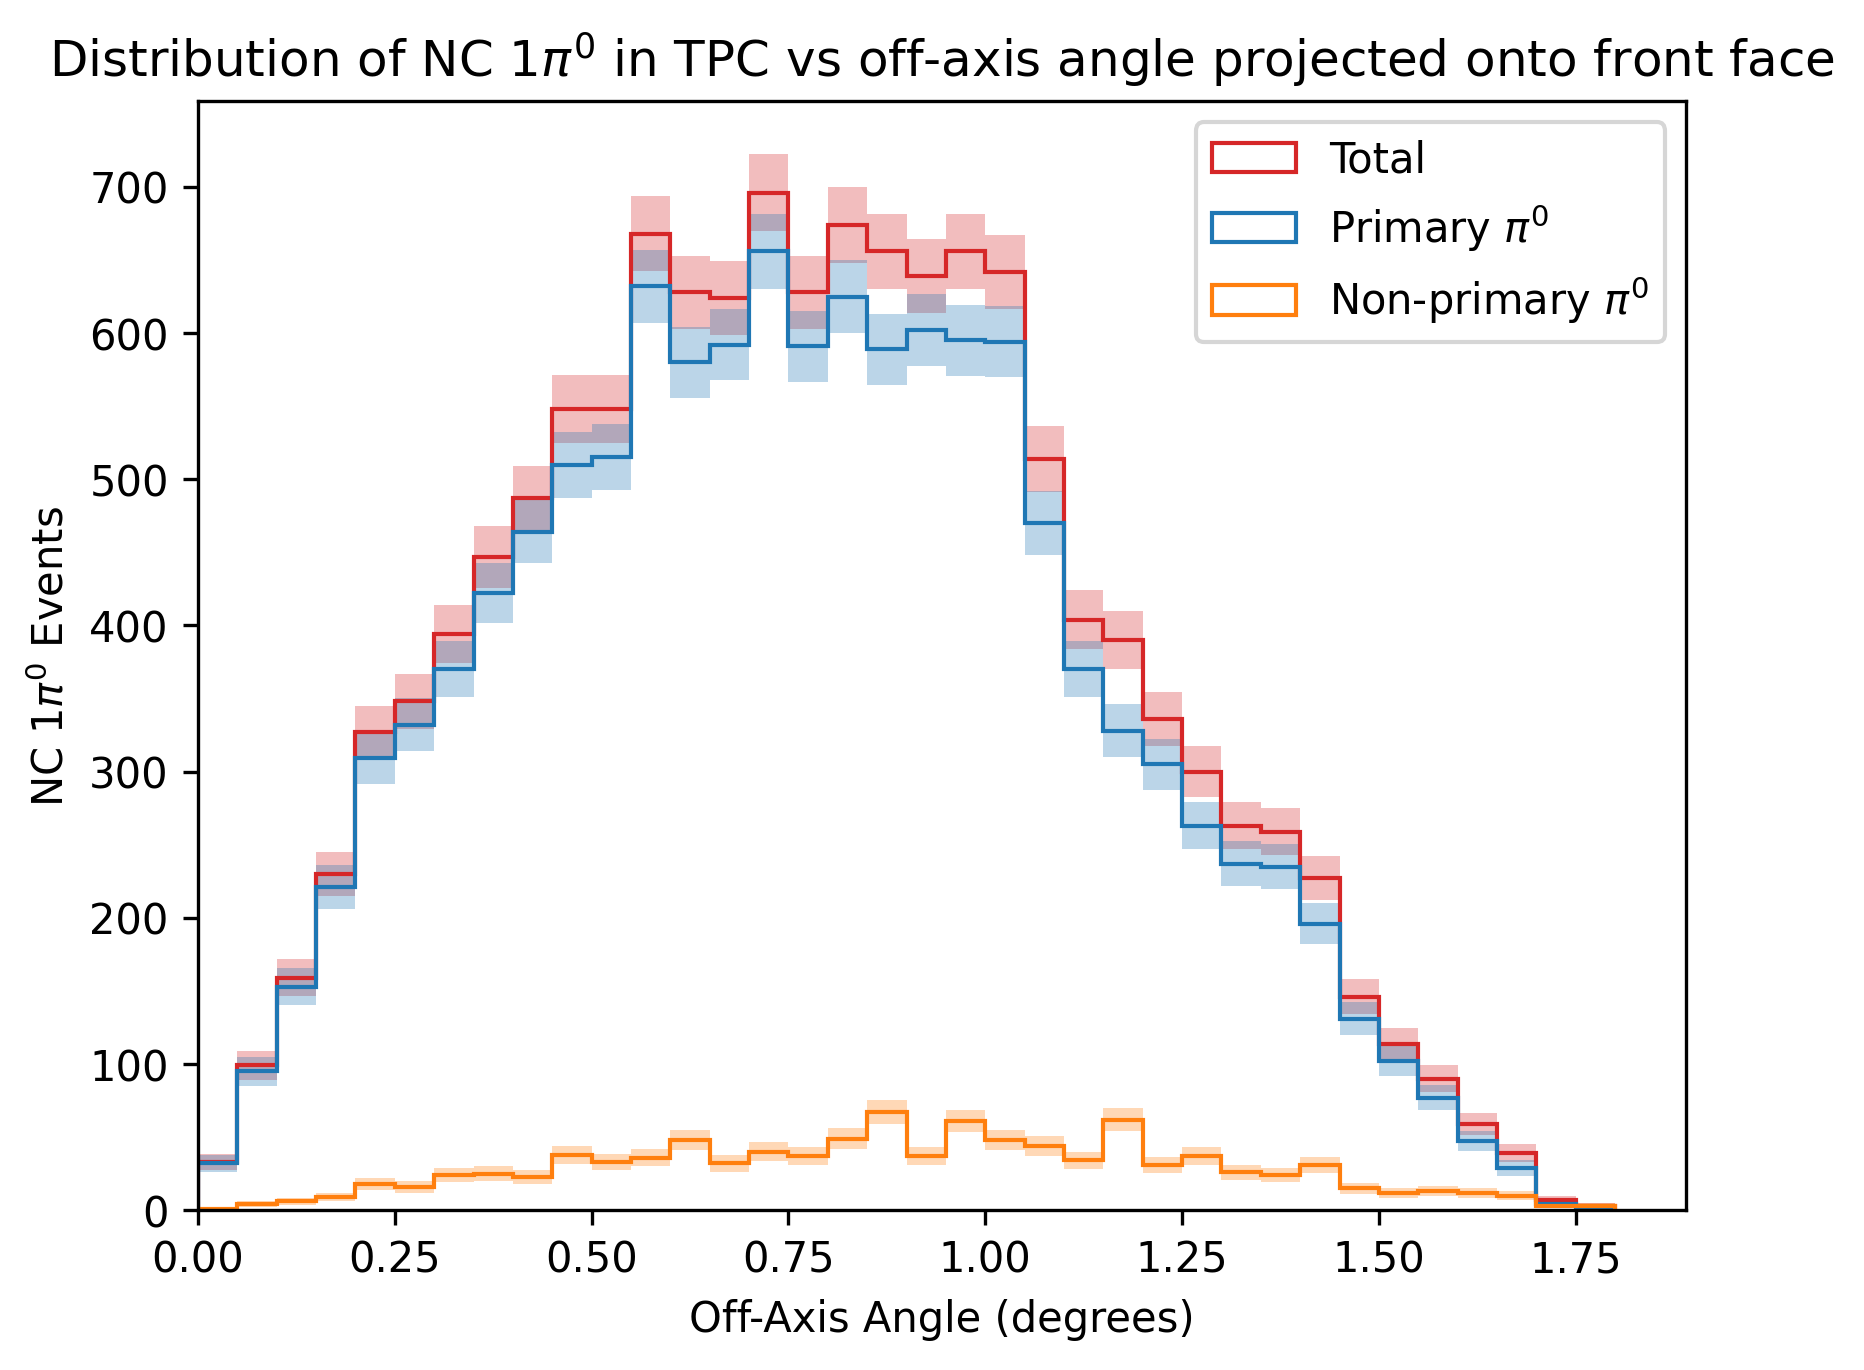

In [18]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_front']) > 0:
        for k in range(len(row['pi0_angle_front'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_front'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_front'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_front'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts
ncP = cP
ncNP = cNP
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts)
errP = np.sqrt(cP)
errNP = np.sqrt(cNP)
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Distribution of NC $1\pi^0$ in TPC vs off-axis angle projected onto front face')
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

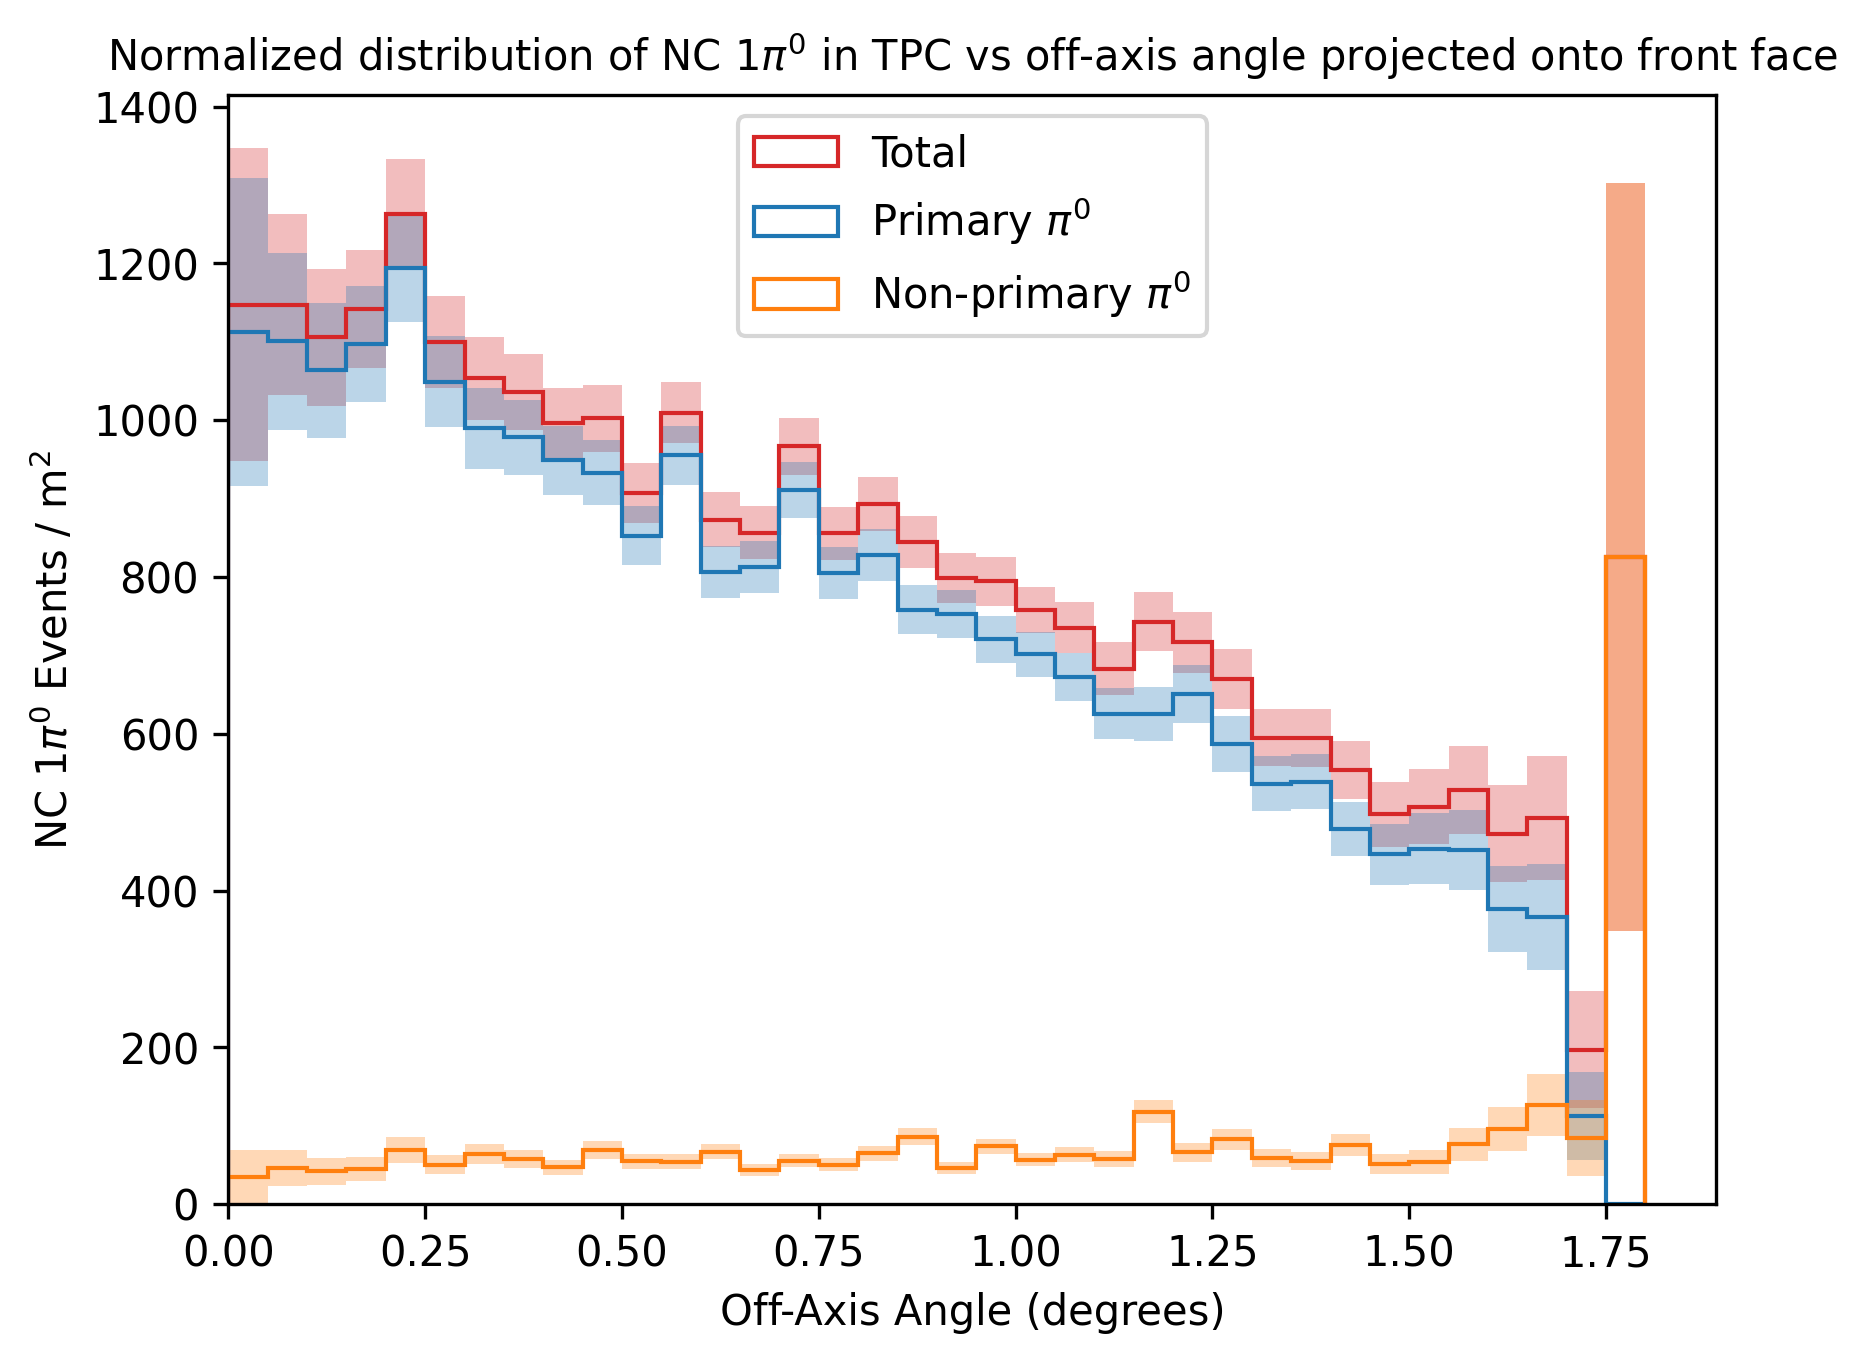

100.0


In [19]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_front']) > 0:
        for k in range(len(row['pi0_angle_front'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_front'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_front'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_front'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts / norm_areas
ncP = cP / norm_areas
ncNP = cNP / norm_areas
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts) / norm_areas
errP = np.sqrt(cP) / norm_areas
errNP = np.sqrt(cNP) / norm_areas
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Normalized distribution of NC $1\pi^0$ in TPC vs off-axis angle projected onto front face', fontsize=10)
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events / m$^2$')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

percentDrop = (ncP[0] - ncP[-1]) / ncP[0] * 100
print(percentDrop)

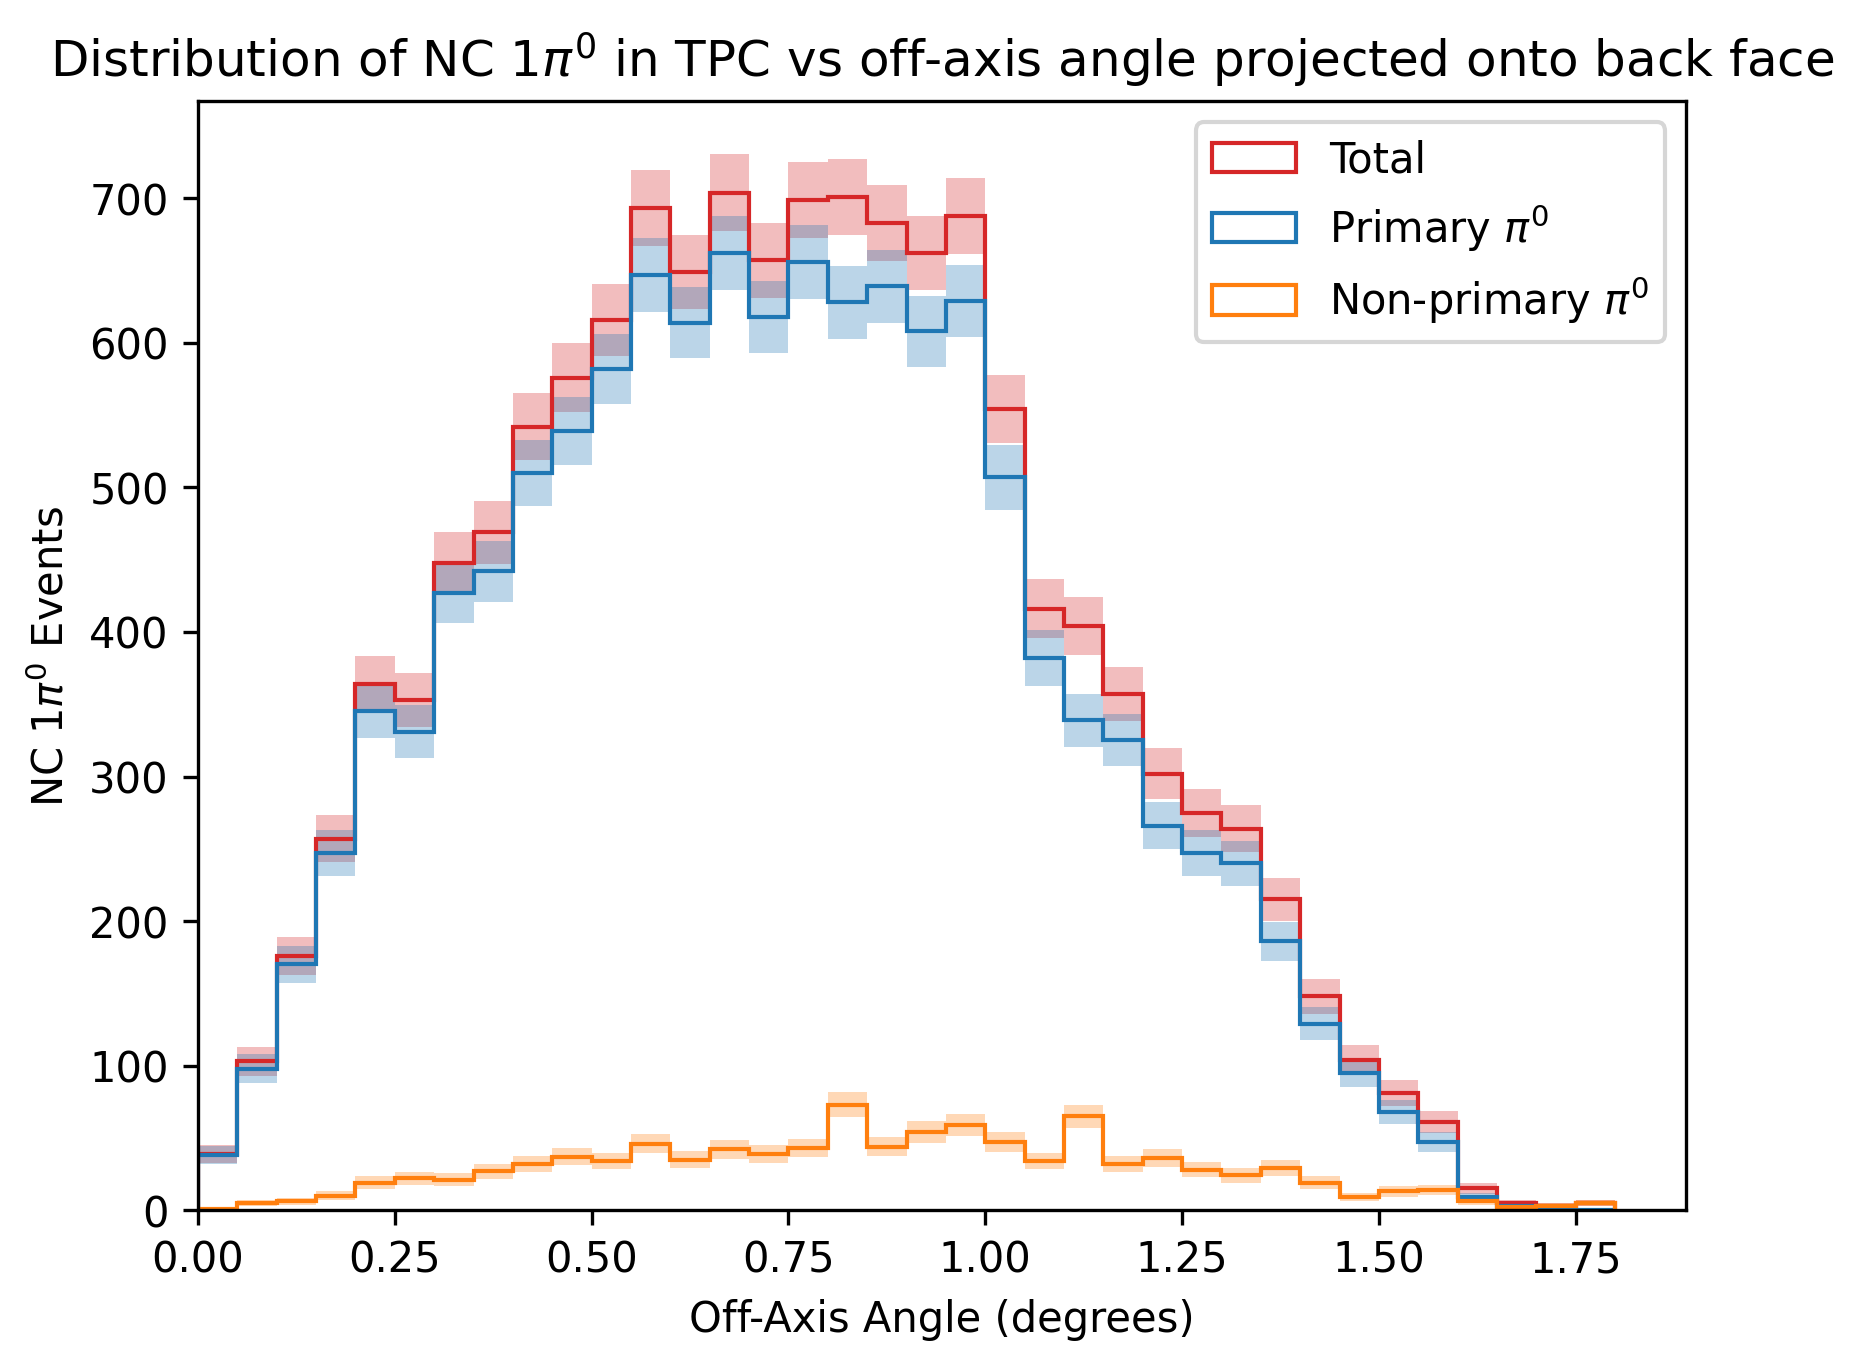

In [20]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_back']) > 0:
        for k in range(len(row['pi0_angle_back'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_back'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_back'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_back'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts
ncP = cP
ncNP = cNP
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts)
errP = np.sqrt(cP)
errNP = np.sqrt(cNP)
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Distribution of NC $1\pi^0$ in TPC vs off-axis angle projected onto back face')
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

/tmp/ipykernel_9602/1711449704.py:19: RuntimeWarning: divide by zero encountered in divide
  norm_counts = counts / norm_areas_back
/tmp/ipykernel_9602/1711449704.py:20: RuntimeWarning: invalid value encountered in divide
  ncP = cP / norm_areas_back
/tmp/ipykernel_9602/1711449704.py:21: RuntimeWarning: divide by zero encountered in divide
  ncNP = cNP / norm_areas_back
/tmp/ipykernel_9602/1711449704.py:24: RuntimeWarning: divide by zero encountered in divide
  errors = np.sqrt(counts) / norm_areas_back
/tmp/ipykernel_9602/1711449704.py:25: RuntimeWarning: invalid value encountered in divide
  errP = np.sqrt(cP) / norm_areas_back
/tmp/ipykernel_9602/1711449704.py:26: RuntimeWarning: divide by zero encountered in divide
  errNP = np.sqrt(cNP) / norm_areas_back
/tmp/ipykernel_9602/1711449704.py:27: RuntimeWarning: invalid value encountered in subtract
  plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
/

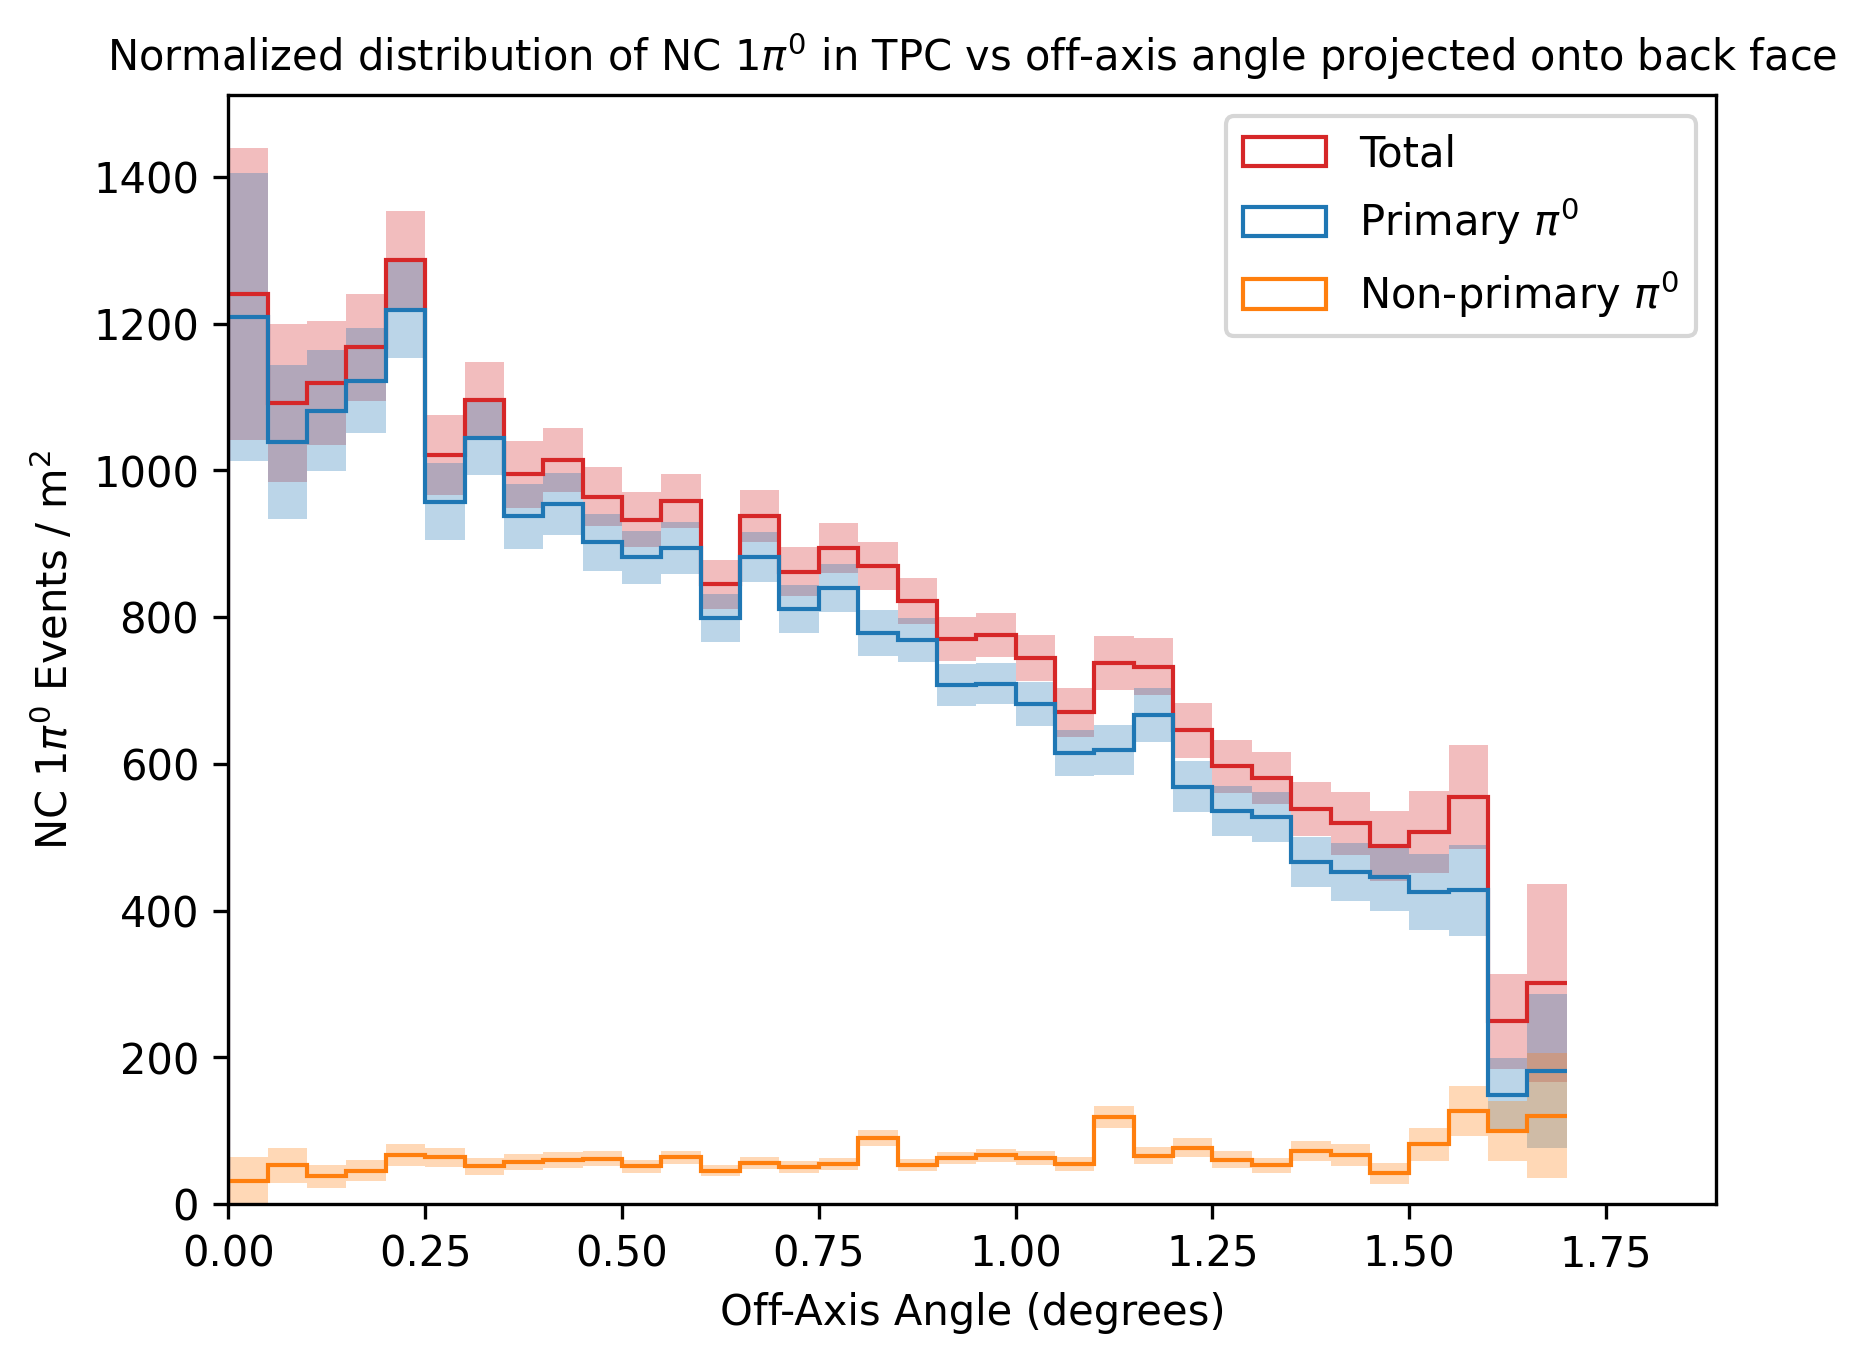

nan


In [21]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_back']) > 0:
        for k in range(len(row['pi0_angle_back'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_back'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_back'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_back'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts / norm_areas_back
ncP = cP / norm_areas_back
ncNP = cNP / norm_areas_back
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts) / norm_areas_back
errP = np.sqrt(cP) / norm_areas_back
errNP = np.sqrt(cNP) / norm_areas_back
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Normalized distribution of NC $1\pi^0$ in TPC vs off-axis angle projected onto back face', fontsize=10)
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events / m$^2$')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

percentDrop = (ncP[0] - ncP[-1]) / ncP[0] * 100
print(percentDrop)

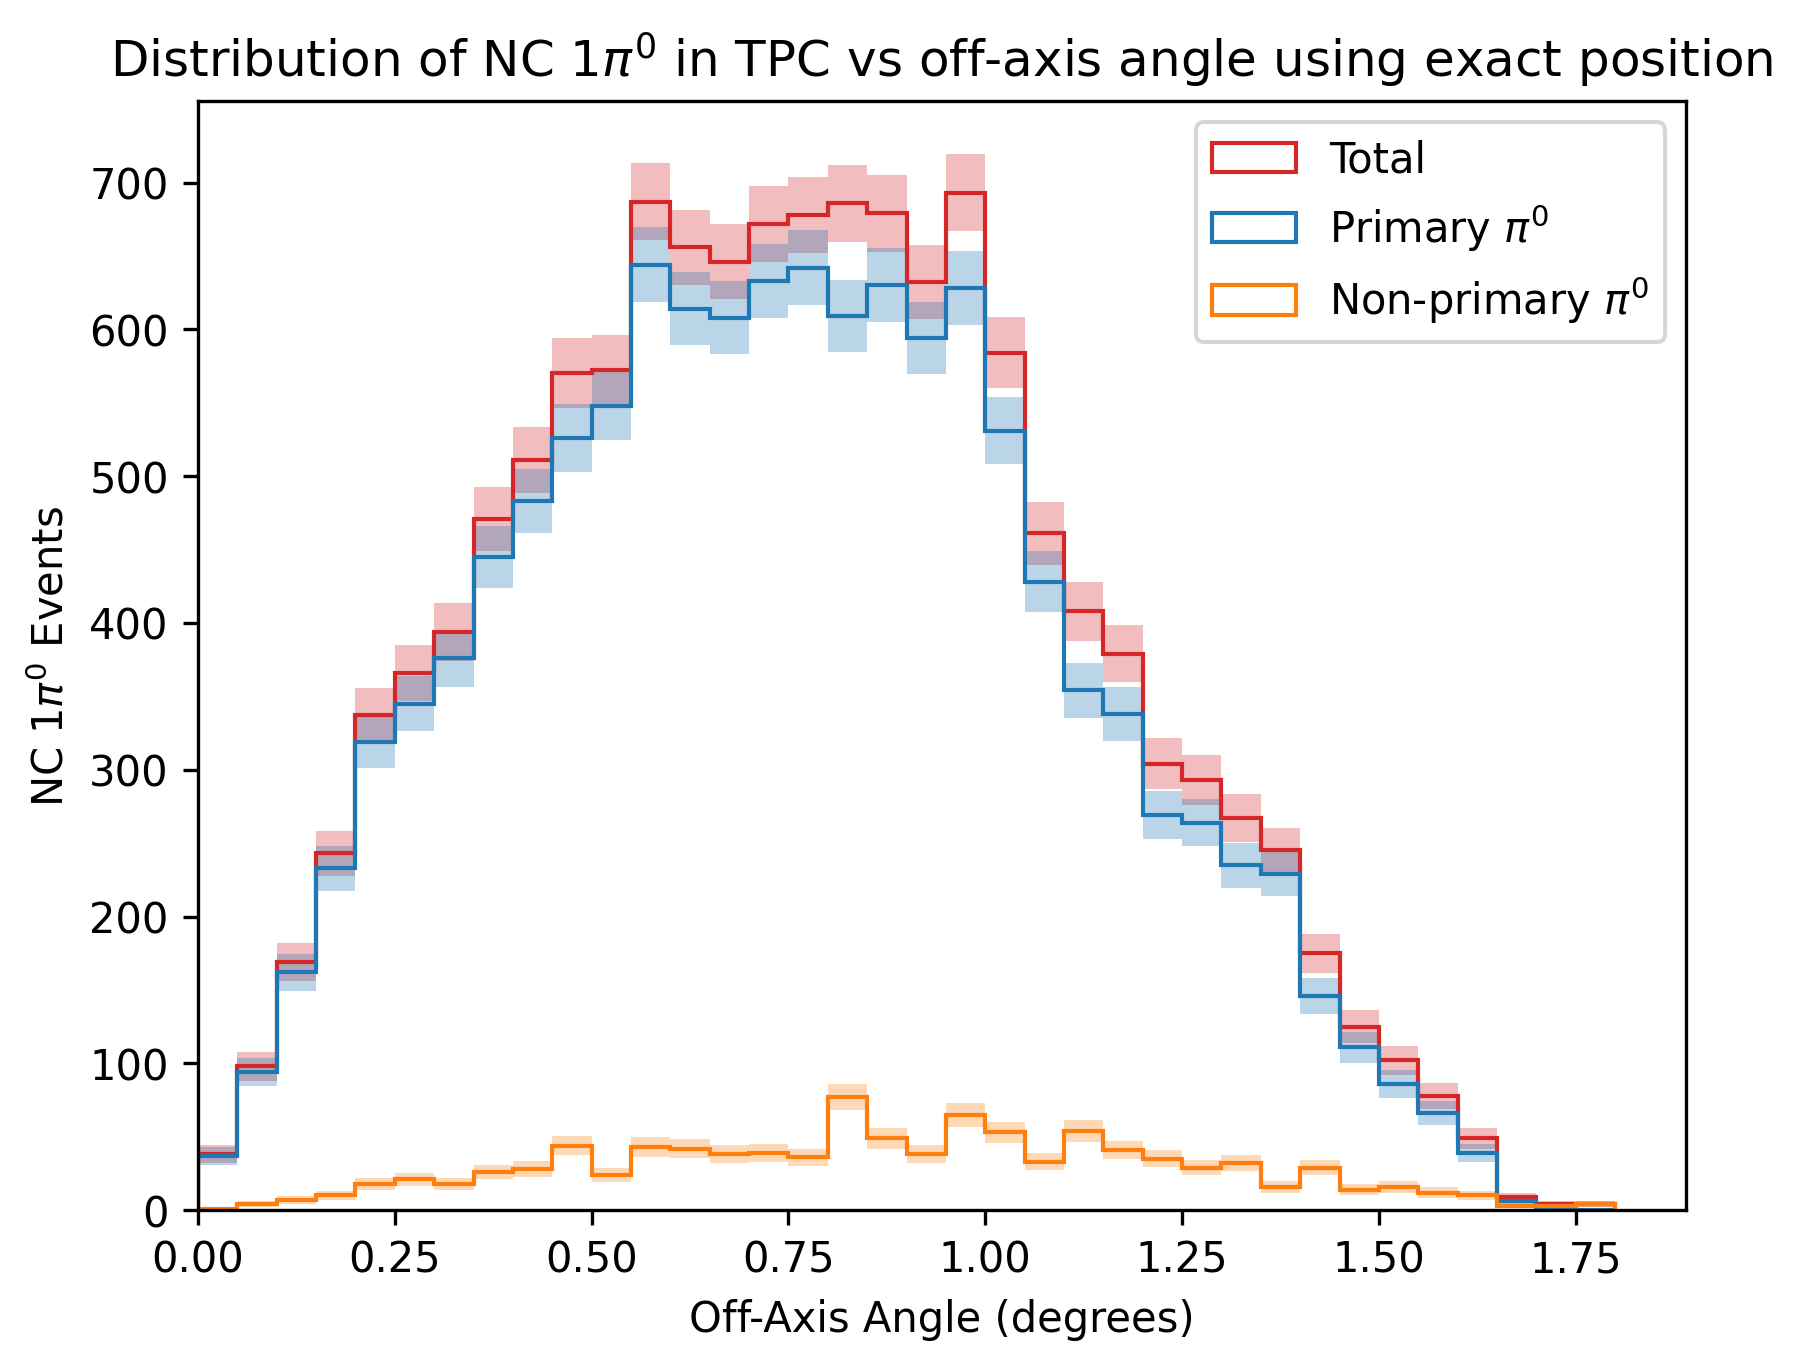

In [22]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_exact']) > 0:
        for k in range(len(row['pi0_angle_exact'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_exact'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_exact'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_exact'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts
ncP = cP
ncNP = cNP
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts)
errP = np.sqrt(cP)
errNP = np.sqrt(cNP)
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Distribution of NC $1\pi^0$ in TPC vs off-axis angle using exact position')
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

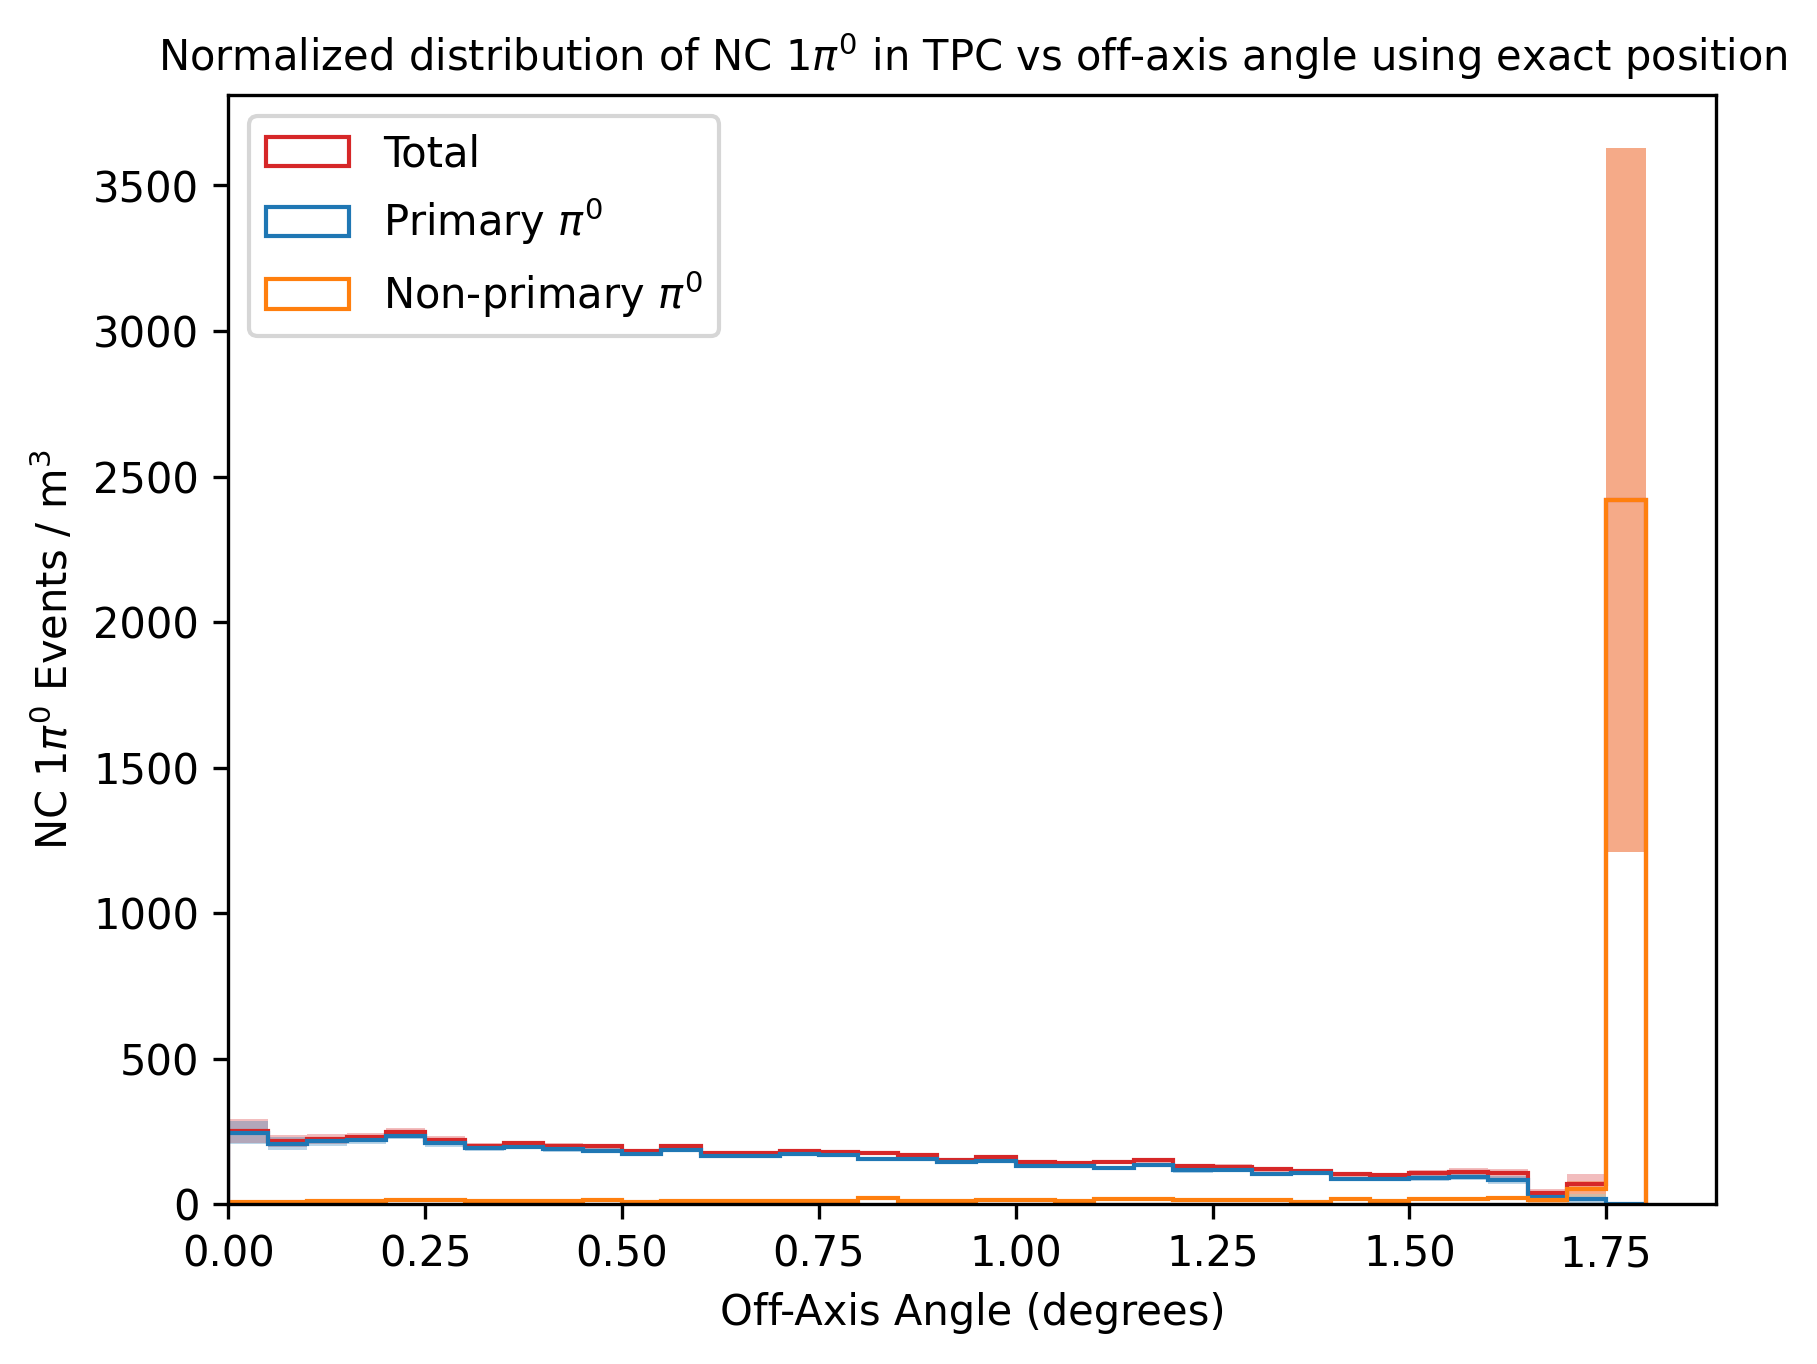

100.0


In [23]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_exact']) > 0:
        for k in range(len(row['pi0_angle_exact'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_exact'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_exact'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_exact'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts / norm_vols
ncP = cP / norm_vols
ncNP = cNP / norm_vols
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts) / norm_vols
errP = np.sqrt(cP) / norm_vols
errNP = np.sqrt(cNP) / norm_vols
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Normalized distribution of NC $1\pi^0$ in TPC vs off-axis angle using exact position', fontsize=10)
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events / m$^3$')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

percentDrop = (ncP[0] - ncP[-1]) / ncP[0] * 100
print(percentDrop)